<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/04_salmonellosis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Machine Learning & Deep Learning

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [48]:
# sklearn
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn import set_config


set_config(transform_output='pandas')
pd.set_option("display.max_rows", None)

## Custom Functions

In [39]:
def calculate_metrics(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r_squared = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r_squared,
    }


## Load and Prepare Data

In [6]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17079 entries, 0 to 17078
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Reporting Area                     17079 non-null  object 
 1   Current MMWR Year                  17079 non-null  int64  
 2   MMWR WEEK                          17079 non-null  int64  
 3   Label                              17079 non-null  object 
 4   Current week                       17079 non-null  int64  
 5   Previous 52 week Max               17079 non-null  float64
 6   Cumulative YTD Current MMWR Year   17079 non-null  int64  
 7   Cumulative YTD Previous MMWR Year  17079 non-null  float64
 8   Season                             17079 non-null  object 
 9   Previous week cases                17079 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 1.3+ MB


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [8]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

In [9]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
Reporting Area,0.409860
Current MMWR Year,0.029276
MMWR WEEK,0.310323
Label,0.005855
Current week,2.769483
Previous 52 week Max,4.209848
Cumulative YTD Current MMWR Year,18.923825
Cumulative YTD Previous MMWR Year,20.106564
Season,0.023421
Previous week cases,2.763628


In [10]:
# see columns and rows where NaN is present in df
df.isna().sum().sum()

np.int64(0)

In [15]:
df["Reporting Area"].value_counts()

,count
Reporting Area,
ALABAMA,244
ALASKA,244
AMERICAN SAMOA,244
ARIZONA,244
ARKANSAS,244
CALIFORNIA,244
COLORADO,244
CONNECTICUT,244
DELAWARE,244


In [17]:
# Remove totals that combine several individual areas.
areas_to_remove = [
    "TOTAL",
    "US RESIDENTS",
    "US TERRITORIES",
    "NON-US RESIDENTS",
    "NEW ENGLAND",
    "MIDDLE ATLANTIC",
    "EAST NORTH CENTRAL",
    "WEST NORTH CENTRAL",
    "SOUTH ATLANTIC",
    "EAST SOUTH CENTRAL",
    "WEST SOUTH CENTRAL",
    "MOUNTAIN",
    "PACIFIC",
]

model_df = df[~df["Reporting Area"].isin(areas_to_remove)].copy()


# Remove the constant label and the feature that contains the target week.
model_df = model_df.drop(
    columns=["Label", "Cumulative YTD Current MMWR Year"],
    errors="ignore",
)

print(f"Rows kept: {len(model_df):,}")
print(f"Reporting areas kept: {model_df['Reporting Area'].nunique()}")


Rows kept: 13,907
Reporting areas kept: 57


 **Decide Which Features to Keep**

The most important rule is that every feature must be known **before** the week being predicted.

| Feature | Decision | Reason |
|---|---|---|
| Reporting Area | Keep | Different areas have different usual case levels. |
| Season | Keep | Cases may follow a seasonal pattern. |
| Previous week cases | Keep | Shows the most recent case level. |
| Previous 52 week Max | Keep | Gives a historical reference for the area. |
| Previous-year cumulative cases | Keep | Shows the area's burden at the same point last year. |
| Current-year cumulative cases | Remove | It already includes the target week's cases, causing data leakage. |
| MMWR WEEK | Remove from model | It overlaps with Season. |
| Current MMWR Year | Split only | Used to order the data, not to predict cases. |
| Label | Remove | It contains the same disease name in every row. |

The two historical summary features may be correlated, but they are not automatically removed. Their usefulness is checked later using feature importance.


In [18]:
# Put every area's weeks in the correct order.
model_df = model_df.sort_values(
    by=["Reporting Area", "Current MMWR Year", "MMWR WEEK"]
).reset_index(drop=True)


# Recalculate previous-week cases within each reporting area.
model_df["Previous week cases"] = (
    model_df
    .groupby("Reporting Area")["Current week"]
    .shift(1)
)


# The first row of each area has no previous week in this dataset.
model_df = model_df.dropna(subset=["Previous week cases"]).reset_index(drop=True)

model_df.head()


,Reporting Area,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,2,3,38.0,12.0,Winter,10.0
1,ALABAMA,2022,3,0,38.0,17.0,Winter,3.0
2,ALABAMA,2022,4,2,38.0,25.0,Winter,0.0
3,ALABAMA,2022,5,0,38.0,30.0,Winter,2.0
4,ALABAMA,2022,6,2,38.0,35.0,Winter,0.0


## EDA

In [19]:
model_df.head(3)

,Reporting Area,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,2,3,38.0,12.0,Winter,10.0
1,ALABAMA,2022,3,0,38.0,17.0,Winter,3.0
2,ALABAMA,2022,4,2,38.0,25.0,Winter,0.0


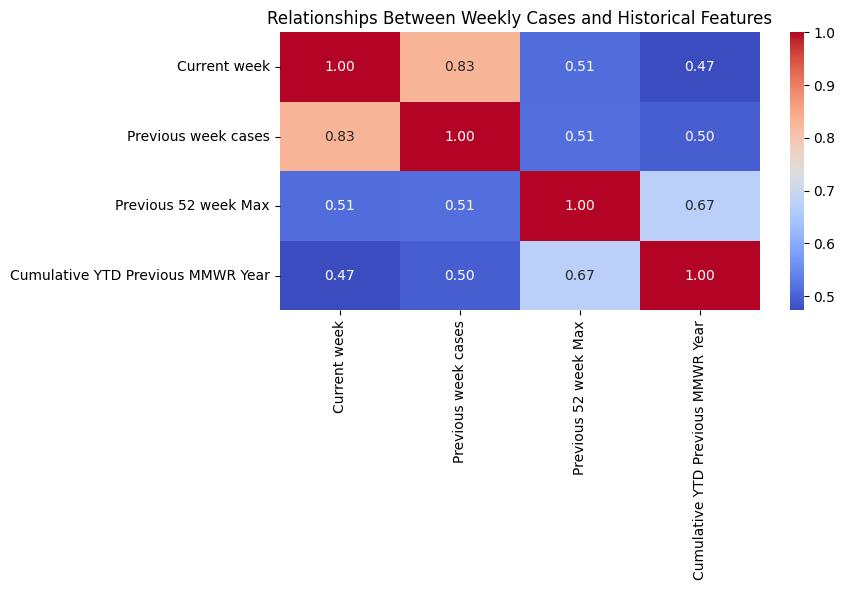

In [24]:
correlation_columns = [
    "Current week",
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
]

correlations = model_df[correlation_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Relationships Between Weekly Cases and Historical Features")
plt.tight_layout()
plt.show()


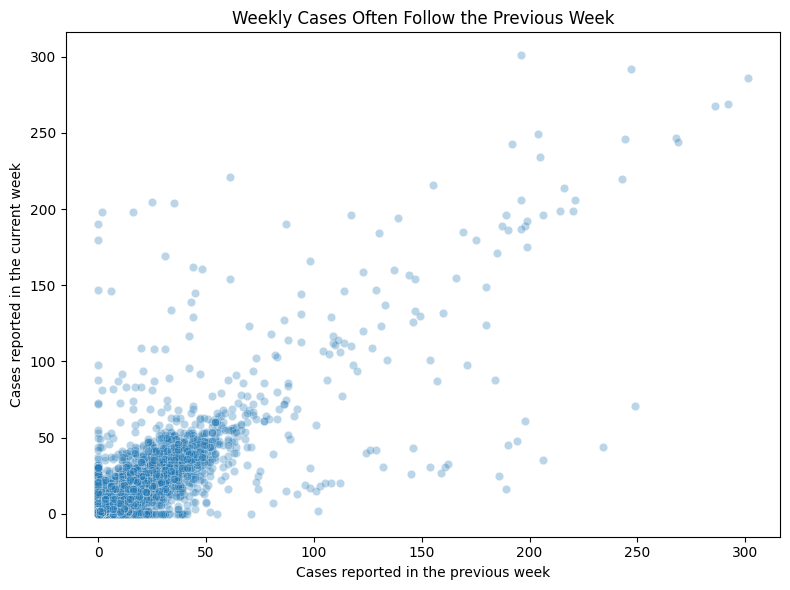

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=model_df,
    x="Previous week cases",
    y="Current week",
    alpha=0.30,
)

plt.title("Weekly Cases Often Follow the Previous Week")
plt.xlabel("Cases reported in the previous week")
plt.ylabel("Cases reported in the current week")
plt.tight_layout()
plt.show()


## Preprocess

In [28]:
target = "Current week"

categorical_features = [
    "Reporting Area",
    "Season",
]

numerical_features = [
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
]

features = categorical_features + numerical_features

# Sort chronologically and split by position
model_df["Time Order"] = model_df["Current MMWR Year"] * 100 + model_df["MMWR WEEK"]
model_df = model_df.sort_values("Time Order")

split_idx = int(len(model_df) * 0.8)
train_df, test_df = model_df.iloc[:split_idx], model_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [29]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

numerical_transformer = StandardScaler()


preprocessor = ColumnTransformer(
    transformers=[
        ("Categories", categorical_transformer, categorical_features),
        ("Numbers", numerical_transformer, numerical_features),
    ]
)


<Axes: xlabel='Current week', ylabel='Count'>

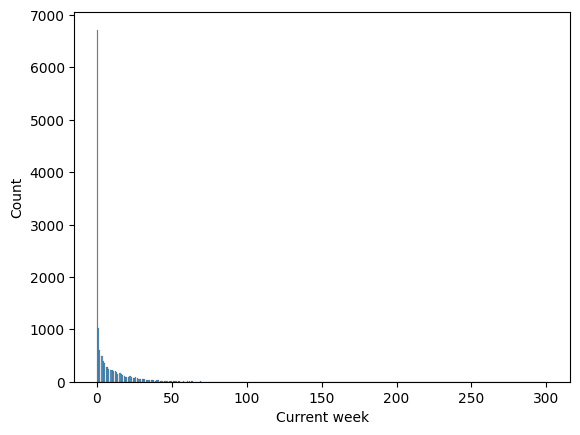

In [37]:
sns.histplot(data=model_df, x="Current week")

In [38]:
X_train.head()

,Reporting Area,Season,Previous week cases,Previous 52 week Max,Cumulative YTD Previous MMWR Year
0,ALABAMA,Winter,10.0,38.0,12.0
3888,INDIANA,Winter,0.0,7.0,16.0
6561,MISSOURI,Winter,0.0,35.0,18.0
6318,MISSISSIPPI,Winter,0.0,27.0,3.0
11663,TEXAS,Winter,2.0,152.0,11.0


## Baseline

In [40]:
# fixed rule that the current week cases will be equal to the previous
baseline_predictions = X_test["Previous week cases"]

baseline_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=baseline_predictions,
    model_name="Previous-week baseline",
)

pd.DataFrame([baseline_metrics]).round(3)


,Model,MAE,RMSE,R²
0,Previous-week baseline,3.432,8.381,0.889


## Model: Linear Regression

In [41]:
linear_model = make_pipeline(
    preprocessor,
    LinearRegression(),
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=linear_predictions,
    model_name="Linear regression",
)

pd.DataFrame([linear_metrics]).round(3)


,Model,MAE,RMSE,R²
0,Linear regression,4.336,10.663,0.82


## Model: Random Forest

In [44]:
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestRegressor(),
)

rf_pipe.fit(X_train, y_train)
forest_predictions = rf_pipe.predict(X_test)

forest_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=forest_predictions,
    model_name="Random forest",
)

pd.DataFrame([forest_metrics]).round(3)

,Model,MAE,RMSE,R²
0,Random forest,4.305,11.313,0.797


In [47]:
# Try different Random Forest settings
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [10, 20, None],
    "randomforestregressor__min_samples_leaf": [2, 5]
}

# Earlier weeks train the model and later weeks validate it
time_split = TimeSeriesSplit(n_splits=5)

gridsearch = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=time_split,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Test every parameter combination
gridsearch.fit(X_train, y_train)

print("Best parameters:")
print(gridsearch.best_params_)

print(
    "Best validation MAE:",
    round(-gridsearch.best_score_, 3)
)

# Save the best fitted Random Forest
best_rf = gridsearch.best_estimator_

# Predict the future test data
gs_pred = best_rf.predict(X_test)

# Evaluate the predictions
gs_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=gs_pred,
    model_name="Tuned Random Forest"
)

pd.DataFrame([gs_metrics]).round(3)

Best parameters:
{'randomforestregressor__max_depth': 10, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 100}
Best validation MAE: 3.942


,Model,MAE,RMSE,R²
0,Tuned Random Forest,4.156,11.613,0.786


## Explanatory Data Analysis


In [50]:
results = pd.DataFrame([
    baseline_metrics,
    linear_metrics,
    forest_metrics,
])

results = results.sort_values("MAE").reset_index(drop=True)
results.round(3)


,Model,MAE,RMSE,R²
0,Previous-week baseline,3.432,8.381,0.889
1,Random forest,4.305,11.313,0.797
2,Linear regression,4.336,10.663,0.820


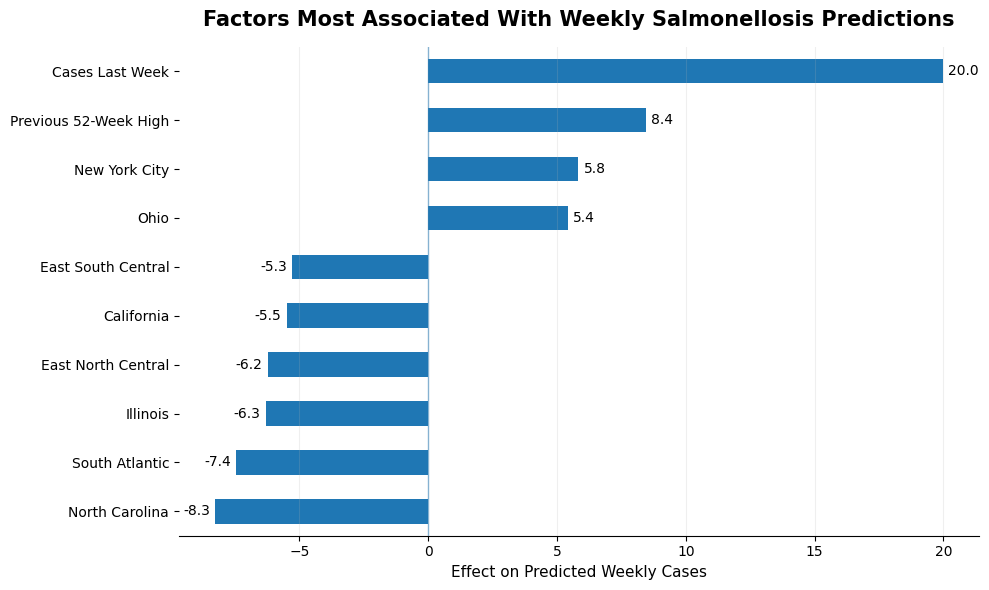

In [60]:
coeffs = plot_linear_coefficients(
    lr_pipe,
    top_n=10)

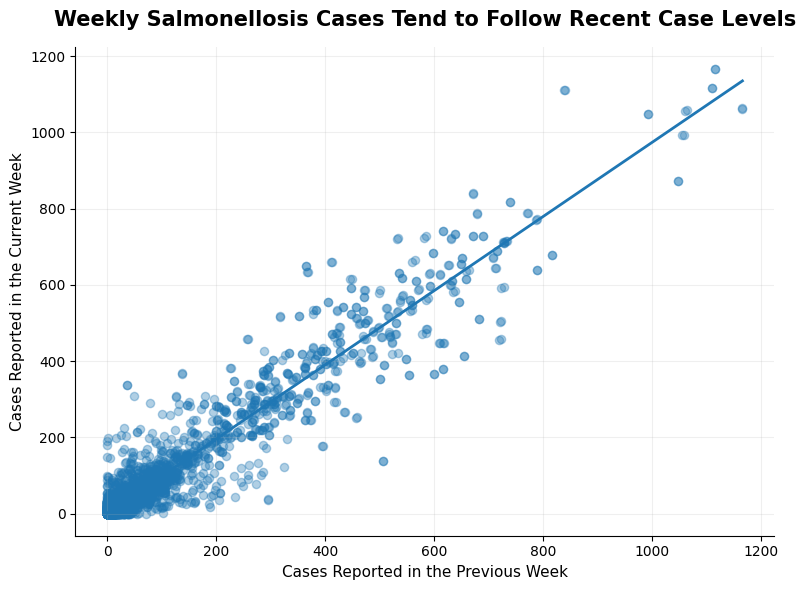

In [63]:
plot_previous_vs_current_week(df);

## Final Model

## Neural Network